# **(ADD THE NOTEBOOK NAME HERE)**

## Objectives

* Write your notebook objective here, for example, "Fetch data from Kaggle and save as raw data", or "engineer features for modelling"

## Inputs

* Write down which data or information you need to run the notebook 

## Outputs

* Write here which files, code or artefacts you generate by the end of the notebook 

## Additional Comments

* If you have any additional comments that don't fit in the previous bullets, please state them here. 



---

# Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [1]:
import os
current_dir = os.getcwd()
current_dir

'/Users/nav/Desktop/Fraud-Analysis/jupyter_notebooks'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [2]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [3]:
current_dir = os.getcwd()
current_dir

'/Users/nav/Desktop/Fraud-Analysis'

# Section 1

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Section 1 content

In [5]:
df = pd.read_csv('Dataset/RawData/synthetic_fraud_dataset.csv')
df.head()

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Timestamp,Account_Balance,Device_Type,Location,Merchant_Category,IP_Address_Flag,...,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Type,Card_Age,Transaction_Distance,Authentication_Method,Risk_Score,Is_Weekend,Fraud_Label
0,TXN_33553,USER_1834,39.79,POS,2023-08-14 19:30:00,93213.17,Laptop,Sydney,Travel,0,...,7,437.63,3,Amex,65,883.17,Biometric,0.8494,0,0
1,TXN_9427,USER_7875,1.19,Bank Transfer,2023-06-07 04:01:00,75725.25,Mobile,New York,Clothing,0,...,13,478.76,4,Mastercard,186,2203.36,Password,0.0959,0,1
2,TXN_199,USER_2734,28.96,Online,2023-06-20 15:25:00,1588.96,Tablet,Mumbai,Restaurants,0,...,14,50.01,4,Visa,226,1909.29,Biometric,0.8400,0,1
3,TXN_12447,USER_2617,254.32,ATM Withdrawal,2023-12-07 00:31:00,76807.20,Tablet,New York,Clothing,0,...,8,182.48,4,Visa,76,1311.86,OTP,0.7935,0,1
4,TXN_39489,USER_2014,31.28,POS,2023-11-11 23:44:00,92354.66,Mobile,Mumbai,Electronics,0,...,14,328.69,4,Mastercard,140,966.98,Password,0.3819,1,1


# Section 2

I will look at the shape of the dataset using .shape

The Dataset has 50,000 rows and 21 columns

In [8]:
df.shape
print("The dataset has {} rows and {} columns".format(df.shape[0], df.shape[1]))

The dataset has 50000 rows and 21 columns


.info() will give me a summary of the dataset which will show if there are any null values in each column as well as what datatype it is. This dataset has no missing values in any columns and states there is 5 float columns, 7 integar columns and 9 object columns

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Transaction_ID                50000 non-null  object 
 1   User_ID                       50000 non-null  object 
 2   Transaction_Amount            50000 non-null  float64
 3   Transaction_Type              50000 non-null  object 
 4   Timestamp                     50000 non-null  object 
 5   Account_Balance               50000 non-null  float64
 6   Device_Type                   50000 non-null  object 
 7   Location                      50000 non-null  object 
 8   Merchant_Category             50000 non-null  object 
 9   IP_Address_Flag               50000 non-null  int64  
 10  Previous_Fraudulent_Activity  50000 non-null  int64  
 11  Daily_Transaction_Count       50000 non-null  int64  
 12  Avg_Transaction_Amount_7d     50000 non-null  float64
 13  F

.columns give me all the columns in the dataset and i have used .tolist() so it displays it as a list. This will help me to see if there are any columns I can remove that wont be useful for my analysis

In [10]:
df.columns.tolist()

['Transaction_ID',
 'User_ID',
 'Transaction_Amount',
 'Transaction_Type',
 'Timestamp',
 'Account_Balance',
 'Device_Type',
 'Location',
 'Merchant_Category',
 'IP_Address_Flag',
 'Previous_Fraudulent_Activity',
 'Daily_Transaction_Count',
 'Avg_Transaction_Amount_7d',
 'Failed_Transaction_Count_7d',
 'Card_Type',
 'Card_Age',
 'Transaction_Distance',
 'Authentication_Method',
 'Risk_Score',
 'Is_Weekend',
 'Fraud_Label']

.describe() provides me with a statistical summary of all the numeric columns, it shows the: Count, Mean, Std, Min, 25%, 50%, 75% and Max.
This helps me spot any obvious data quality issues such as outliers and negative values where there should'nt be. Ive rounded it to 2 decimal places to make it easier to read

In [13]:
df.describe().round(2)

,Transaction_Amount,Account_Balance,IP_Address_Flag,Previous_Fraudulent_Activity,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Age,Transaction_Distance,Risk_Score,Is_Weekend,Fraud_Label
count,50000.00,50000.00,50000.00,50000.0,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00
mean,99.41,50294.07,0.05,0.1,7.49,255.27,2.00,120.00,2499.16,0.50,0.30,0.32
std,98.69,28760.46,0.22,0.3,4.04,141.38,1.41,68.99,1442.01,0.29,0.46,0.47
min,0.00,500.48,0.00,0.0,1.00,10.00,0.00,1.00,0.25,0.00,0.00,0.00
25%,28.68,25356.00,0.00,0.0,4.00,132.09,1.00,60.00,1256.50,0.25,0.00,0.00
50%,69.66,50384.43,0.00,0.0,7.00,256.08,2.00,120.00,2490.78,0.50,0.00,0.00
75%,138.85,75115.14,0.00,0.0,11.00,378.03,3.00,180.00,3746.40,0.75,1.00,1.00
max,1174.14,99998.31,1.00,1.0,14.00,500.00,4.00,239.00,4999.93,1.00,1.00,1.00


.describe(include='object') provides me with a statistical summary of all the categorical (text-based) columns, it shows the: Count, Unique, Top and Freq.
This helps me check that each category has a sensible number of unique values and spot any inconsistent labelling, such as duplicate categories caused by different spelling or casing (e.g. "Mobile" vs "mobile").


In [14]:
df.describe(include='object')

,Transaction_ID,User_ID,Transaction_Type,Timestamp,Device_Type,Location,Merchant_Category,Card_Type,Authentication_Method
count,50000,50000,50000,50000,50000,50000,50000,50000,50000
unique,50000,8963,4,47724,3,5,5,4,4
top,TXN_33553,USER_6599,POS,2023-06-04 06:35:00,Tablet,Tokyo,Clothing,Mastercard,Biometric
freq,1,16,12549,4,16779,10208,10033,12693,12591


Looking at the output, `Transaction_Type` has 4 unique values , `Device_Type` has 3, `Location` has 5, `Merchant_Category` has 5, `Card_Type` has 4, and `Authentication_Method` has 4 — all sensible, low counts with no obvious spelling or casing inconsistencies. `Transaction_ID` is fully unique as expected for an identifier, and `User_ID` has 8,963 unique values across 50,000 rows, showing some users made multiple transactions (the most frequent user appears 16 times).

---

## Data Cleaning

### Missing values

To check missing values I will use .isnull().sum. This will show me if there any missing values in any columns

In [15]:
df.isnull().sum()

Transaction_ID                  0
User_ID                         0
Transaction_Amount              0
Transaction_Type                0
Timestamp                       0
Account_Balance                 0
Device_Type                     0
Location                        0
Merchant_Category               0
IP_Address_Flag                 0
Previous_Fraudulent_Activity    0
Daily_Transaction_Count         0
Avg_Transaction_Amount_7d       0
Failed_Transaction_Count_7d     0
Card_Type                       0
Card_Age                        0
Transaction_Distance            0
Authentication_Method           0
Risk_Score                      0
Is_Weekend                      0
Fraud_Label                     0
dtype: int64

### Duplicates
I will check to see if there any duplicate rows in the dataset and remove them accordingly if there are

In [17]:
df.duplicated().sum()
print("There is {} duplicates in this dataset".format(df.duplicated().sum()))

There is 0 duplicates in this dataset


 When looking at df.info() I saw that Timestamp is  stored as an object (text) rather than a proper datetime, which means I can't use it to extract things like hour or day of week yet. I changed Timestamp to the correct datatype so that i can create a seperate date and time column

In [26]:
# Convert Timestamp from text to a proper datetime type
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
print(df['Timestamp'].dtype)

datetime64[ns]


I've also checked the binary/flag columns to make sure they're stored consistently as whole numbers rather than mixed types.

In [25]:
binary_cols = ['IP_Address_Flag', 'Previous_Fraudulent_Activity', 'Is_Weekend', 'Fraud_Label']
df[binary_cols].dtypes

IP_Address_Flag                 int64
Previous_Fraudulent_Activity    int64
Is_Weekend                      int64
Fraud_Label                     int64
dtype: object

All four binary/flag columns (IP_Address_Flag, Previous_Fraudulent_Activity, Is_Weekend, Fraud_Label) are correctly stored as int64 so I will not need to convert them.

### Outlier Checks

I will check the numeric columns for outliers. Values that sit unusually far from the rest of the data. I'm using box plots to visualise this, as they clearly show the spread of the data (via the quartiles) and flag any points that fall outside the expected range. For each outlier found, I'll need to decide whether it's a genuine extreme case (e.g. a large but real transaction) or a data error that needs handling.

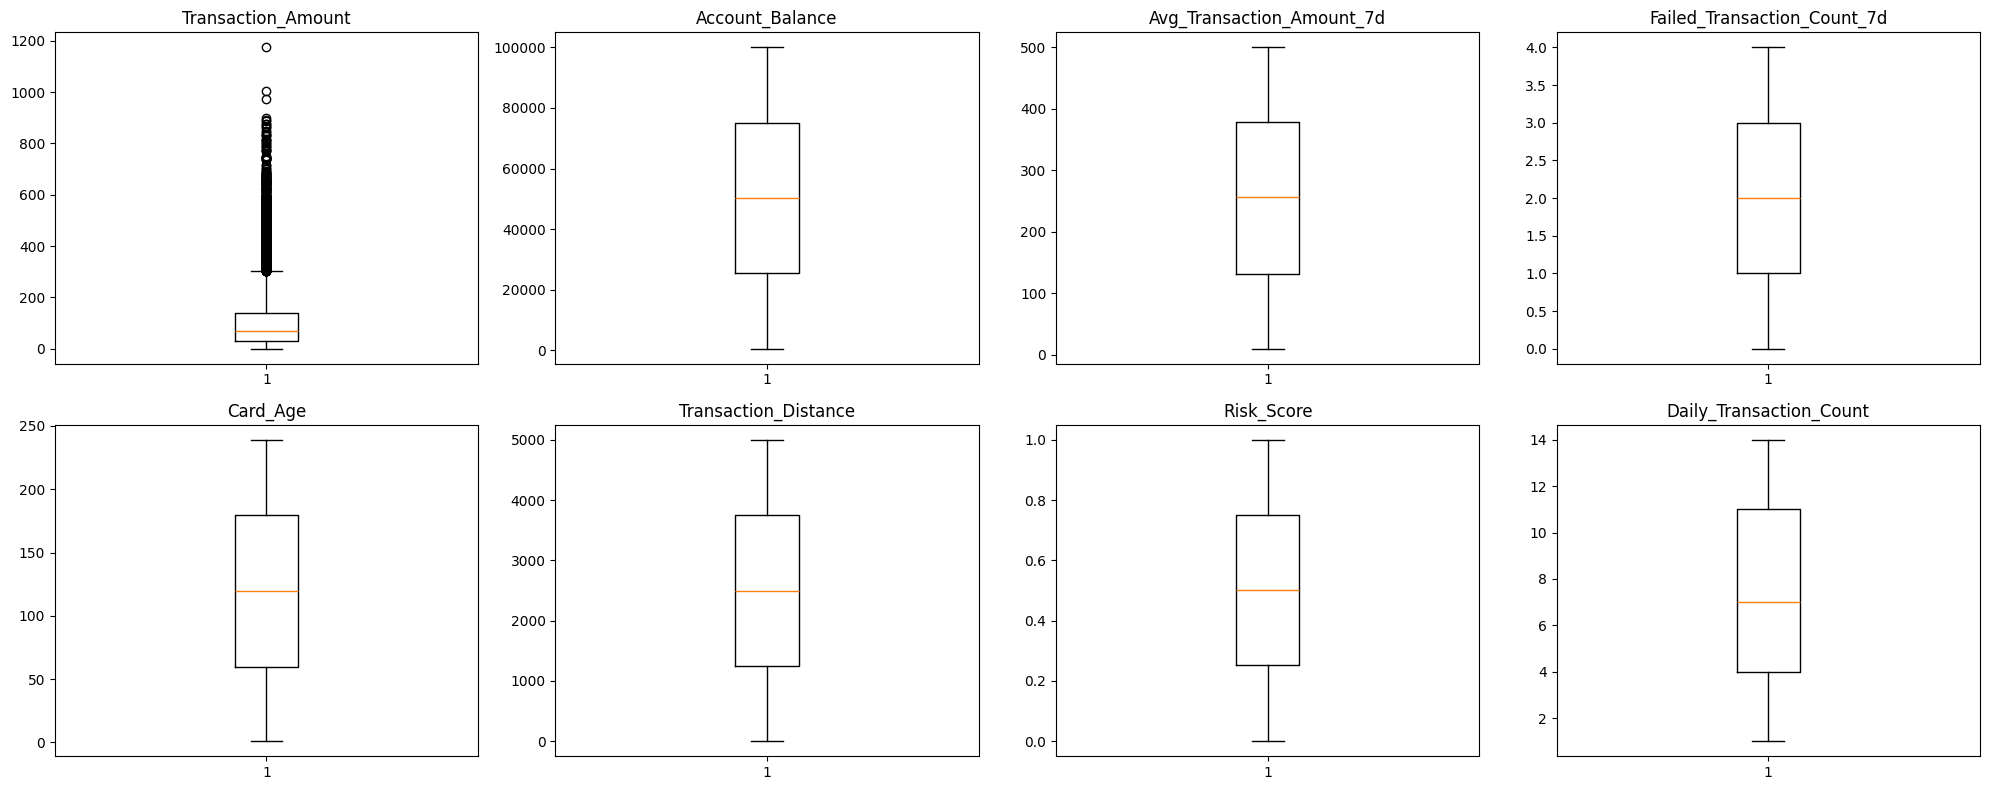

In [29]:
numeric_cols = ['Transaction_Amount', 'Account_Balance', 'Avg_Transaction_Amount_7d',
                 'Failed_Transaction_Count_7d', 'Card_Age', 'Transaction_Distance',
                 'Risk_Score', 'Daily_Transaction_Count']

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

Looking at the box plots Transaction_Amount is the only column with a noticeable number of outliers — a fair number of transactions are higher than the rest. None of these are negative or look like errors, they're just genuinely larger transactions, so I'm keeping them in rather than removing them — a high amount might actually be useful for spotting fraud later on.

All the other columns Account_Balance, Avg_Transaction_Amount_7d, Failed_Transaction_Count_7d, Card_Age, Transaction_Distance, Risk_Score, Daily_Transaction_Count don't show any real outliers — the values all sit within a normal, expected range with nothing negative or unusual.

### Categorical value checks

This section checks the unique values in each categorical (text) column, to spot any inconsistent labelling — like the same category appearing twice with different spelling or capitalisation (e.g. "Mobile" vs "mobile").

In [30]:
Categorical_cols = ['Transaction_Type', 'Device_Type', 'Location', 'Merchant_Category', 'Card_Type', 'Authentication_Method']

for col in Categorical_cols:
    print(col)
    print(df[col].unique())
    print()

Transaction_Type
['POS' 'Bank Transfer' 'Online' 'ATM Withdrawal']

Device_Type
['Laptop' 'Mobile' 'Tablet']

Location
['Sydney' 'New York' 'Mumbai' 'Tokyo' 'London']

Merchant_Category
['Travel' 'Clothing' 'Restaurants' 'Electronics' 'Groceries']

Card_Type
['Amex' 'Mastercard' 'Visa' 'Discover']

Authentication_Method
['Biometric' 'Password' 'OTP' 'PIN']



There were no inconsistencies each column has a small sensible number of clearly distinct categories, with no duplicates caused by spelling or capitalisation errors.

### Feature engineering

I am going to create new columns from Timestamp that I'll need later for hypothesis testing , specifically hour and day_of_week. I need this for one of my hypotheses and Timestamp on its own isn't something I can group or compare by directly.

In [31]:
df['hour'] = df['Timestamp'].dt.hour
df['day_of_week'] = df['Timestamp'].dt.day_name()

df[['Timestamp', 'hour', 'day_of_week', 'Is_Weekend']].head()

,Timestamp,hour,day_of_week,Is_Weekend
0,2023-08-14 19:30:00,19,Monday,0
1,2023-06-07 04:01:00,4,Wednesday,0
2,2023-06-20 15:25:00,15,Tuesday,0
3,2023-12-07 00:31:00,0,Thursday,0
4,2023-11-11 23:44:00,23,Saturday,1


### Drop unused columns

I have pulled the hour and day of week out of Timestamp and I don't need the original column anymore. I'm also dropping User_ID since it's just an identifier and IP_Address_Flag since it isn't something I'll be testing or using in my model. I am keeping the rest of the columns as they may still be useful for the machine learning model later.

In [34]:
df = df.drop(columns=['Timestamp', 'User_ID', 'IP_Address_Flag'])
df.head()

,Transaction_ID,Transaction_Amount,Transaction_Type,Account_Balance,Device_Type,Location,Merchant_Category,Previous_Fraudulent_Activity,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Type,Card_Age,Transaction_Distance,Authentication_Method,Risk_Score,Is_Weekend,Fraud_Label,hour,day_of_week
0,TXN_33553,39.79,POS,93213.17,Laptop,Sydney,Travel,0,7,437.63,3,Amex,65,883.17,Biometric,0.8494,0,0,19,Monday
1,TXN_9427,1.19,Bank Transfer,75725.25,Mobile,New York,Clothing,0,13,478.76,4,Mastercard,186,2203.36,Password,0.0959,0,1,4,Wednesday
2,TXN_199,28.96,Online,1588.96,Tablet,Mumbai,Restaurants,0,14,50.01,4,Visa,226,1909.29,Biometric,0.8400,0,1,15,Tuesday
3,TXN_12447,254.32,ATM Withdrawal,76807.20,Tablet,New York,Clothing,0,8,182.48,4,Visa,76,1311.86,OTP,0.7935,0,1,0,Thursday
4,TXN_39489,31.28,POS,92354.66,Mobile,Mumbai,Electronics,1,14,328.69,4,Mastercard,140,966.98,Password,0.3819,1,1,23,Saturday


## Saving the cleaned dataset in the cleaned data folder

In [36]:
# save the cleaned dataset to a new CSV file
df.to_csv('Dataset/CleanData/cleaned_fraud_dataset.csv', index=False)
print("Cleaned dataset saved to 'Dataset/CleanData/cleaned_fraud_dataset.csv'!")

Cleaned dataset saved to 'Dataset/CleanData/cleaned_fraud_dataset.csv'!


# Push files to Repo

* In cases where you don't need to push files to Repo, you may replace this section with "Conclusions and Next Steps" and state your conclusions and next steps.

In [6]:
import os
try:
  # create your folder here
  # os.makedirs(name='')
except Exception as e:
  print(e)


IndentationError: expected an indented block after 'try' statement on line 2 (553063055.py, line 5)